# Credit Card Fraud Detection System

## Phase 1 -- Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('credit_card_fraud_dataset.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (500, 17)


In [3]:
df.head(10)

,transaction_id,transaction_amount_inr,transaction_hour,day_of_week,merchant_category,is_high_risk_merchant,card_present,location_match,distance_from_home_km,prev_txn_gap_mins,num_txn_last_24h,num_declined_last_7days,cvv_mismatch,international_transaction,customer_age_years,account_age_days,is_fraud
0,1,13739.72,18,Fri,healthcare,0,1,1,26.9,2791.7,3,2,0,0,39,3219,0
1,2,6339.63,20,Wed,online_shopping,1,1,0,7.3,792.1,4,0,0,0,43,2640,0
2,3,1826.62,20,Mon,grocery,0,1,1,6.6,840.6,4,0,0,0,30,325,0
3,4,1826.37,10,Tue,restaurant,0,1,1,33.3,511.9,2,2,0,0,64,1254,0
4,5,848.91,22,Thu,entertainment,0,1,1,36.8,1785.6,3,0,0,0,37,3156,0
5,6,3811.40,16,Wed,fuel,0,0,1,28.1,827.5,4,0,0,0,35,3230,0
6,7,708.73,16,Wed,grocery,0,1,1,14.2,993.6,3,0,0,0,58,3341,0
7,8,246.04,21,Fri,restaurant,0,1,1,15.4,216.8,1,0,0,0,52,2128,0
8,9,2047.93,19,Mon,grocery,0,1,1,16.9,1016.4,1,0,0,0,44,2254,0
9,10,601.11,9,Thu,utilities,0,1,1,17.3,2798.8,4,0,0,0,24,2631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             500 non-null    int64  
 1   transaction_amount_inr     500 non-null    float64
 2   transaction_hour           500 non-null    int64  
 3   day_of_week                500 non-null    object 
 4   merchant_category          500 non-null    object 
 5   is_high_risk_merchant      500 non-null    int64  
 6   card_present               500 non-null    int64  
 7   location_match             500 non-null    int64  
 8   distance_from_home_km      500 non-null    float64
 9   prev_txn_gap_mins          500 non-null    float64
 10  num_txn_last_24h           500 non-null    int64  
 11  num_declined_last_7days    500 non-null    int64  
 12  cvv_mismatch               500 non-null    int64  
 13  international_transaction  500 non-null    int64  

In [5]:
df.describe().round(2)

,transaction_id,transaction_amount_inr,transaction_hour,is_high_risk_merchant,card_present,location_match,distance_from_home_km,prev_txn_gap_mins,num_txn_last_24h,num_declined_last_7days,cvv_mismatch,international_transaction,customer_age_years,account_age_days,is_fraud
count,500.00,500.00,500.00,500.0,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,6806.79,13.05,0.2,0.78,0.88,120.39,1452.06,2.98,0.26,0.06,0.09,42.25,1766.68,0.05
std,144.48,11552.59,4.23,0.4,0.41,0.32,514.75,892.11,2.49,0.64,0.23,0.29,12.79,1044.80,0.22
min,1.00,131.89,0.00,0.0,0.00,0.00,0.00,0.80,1.00,0.00,0.00,0.00,18.00,33.00,0.00
25%,125.75,1395.68,10.00,0.0,1.00,1.00,10.38,679.50,2.00,0.00,0.00,0.00,31.00,917.50,0.00
50%,250.50,2482.54,13.00,0.0,1.00,1.00,20.75,1448.95,3.00,0.00,0.00,0.00,42.00,1694.00,0.00
75%,375.25,6124.71,16.00,0.0,1.00,1.00,30.72,2261.00,4.00,0.00,0.00,0.00,54.00,2726.25,0.00
max,500.00,81723.26,23.00,1.0,1.00,1.00,4866.00,2998.70,19.00,4.00,1.00,1.00,64.00,3637.00,1.00


In [6]:
# checking for missing values
df.isnull().sum()

transaction_id               0
transaction_amount_inr       0
transaction_hour             0
day_of_week                  0
merchant_category            0
is_high_risk_merchant        0
card_present                 0
location_match               0
distance_from_home_km        0
prev_txn_gap_mins            0
num_txn_last_24h             0
num_declined_last_7days      0
cvv_mismatch                 0
international_transaction    0
customer_age_years           0
account_age_days             0
is_fraud                     0
dtype: int64

In [7]:
# categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()}")

day_of_week: 7 unique -> ['Fri' 'Wed' 'Mon' 'Tue' 'Thu' 'Sat' 'Sun']
merchant_category: 12 unique -> ['healthcare' 'online_shopping' 'grocery' 'restaurant' 'entertainment'
 'fuel' 'utilities' 'electronics' 'cash_advance' 'retail_clothing'
 'jewelry' 'travel']


In [8]:
# quick look at fraud vs genuine counts
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Genuine: {fraud_counts[0]} ({fraud_pct[0]:.1f}%)")
print(f"Fraud:   {fraud_counts[1]} ({fraud_pct[1]:.1f}%)")

Genuine: 475 (95.0%)
Fraud:   25 (5.0%)


No missing values. Two categorical columns (merchant_category, day_of_week) will need encoding later. Dataset is imbalanced as expected -- will handle with SMOTE.

---
## Phase 2 -- Exploratory Data Analysis (EDA)

### Plot 1 -- Class Distribution (Fraud vs Genuine)

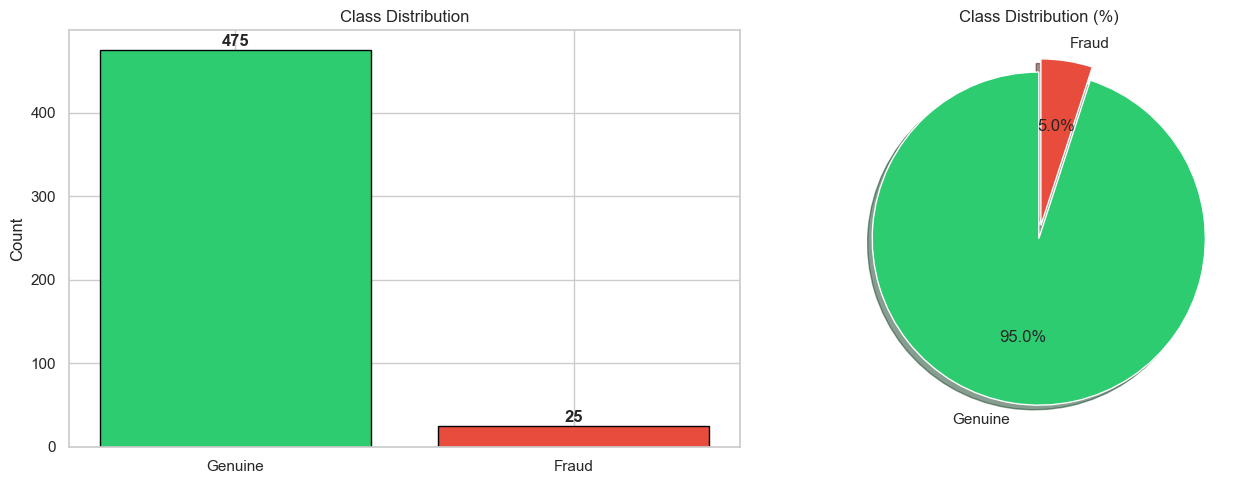

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
labels = ['Genuine', 'Fraud']
counts = df['is_fraud'].value_counts().sort_index()

# bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.08), shadow=True)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Heavy class imbalance confirmed. A model that just predicts "genuine" every time would get high accuracy but miss all fraud. SMOTE is necessary.

### Plot 2 -- Transaction Amount (Fraud vs Genuine)

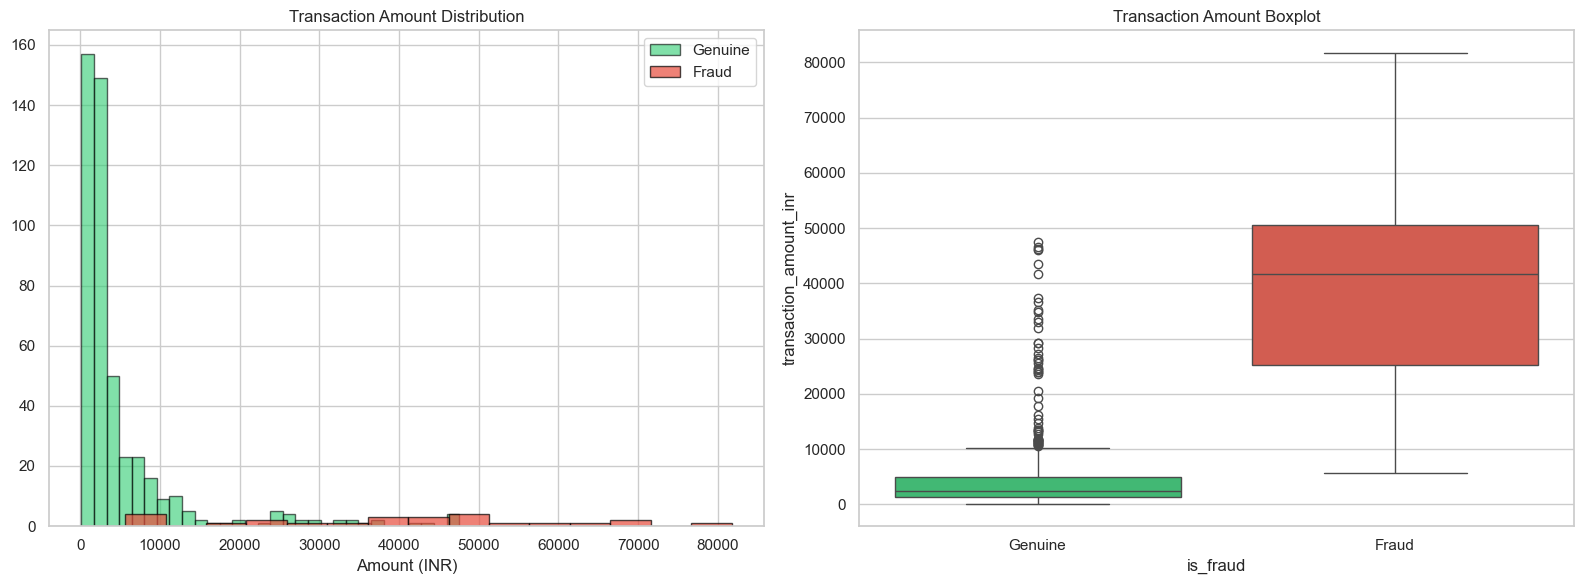

Genuine avg: 5,072 INR | Fraud avg: 39,767 INR


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genuine_amt = df[df['is_fraud'] == 0]['transaction_amount_inr']
fraud_amt = df[df['is_fraud'] == 1]['transaction_amount_inr']

# histogram
axes[0].hist(genuine_amt, bins=30, alpha=0.6, label='Genuine', color='#2ecc71', edgecolor='black')
axes[0].hist(fraud_amt, bins=15, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (INR)')
axes[0].legend()

# boxplot
df_temp = df[['transaction_amount_inr', 'is_fraud']].copy()
df_temp['is_fraud'] = df_temp['is_fraud'].map({0: 'Genuine', 1: 'Fraud'})
sns.boxplot(data=df_temp, x='is_fraud', y='transaction_amount_inr',
            palette={'Genuine': '#2ecc71', 'Fraud': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Transaction Amount Boxplot')

plt.tight_layout()
plt.savefig('plots/02_transaction_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Genuine avg: {genuine_amt.mean():,.0f} INR | Fraud avg: {fraud_amt.mean():,.0f} INR")

Fraud transactions involve significantly higher amounts. Fraudsters try to extract maximum value per transaction.

### Plot 3 -- Transaction Hour Patterns

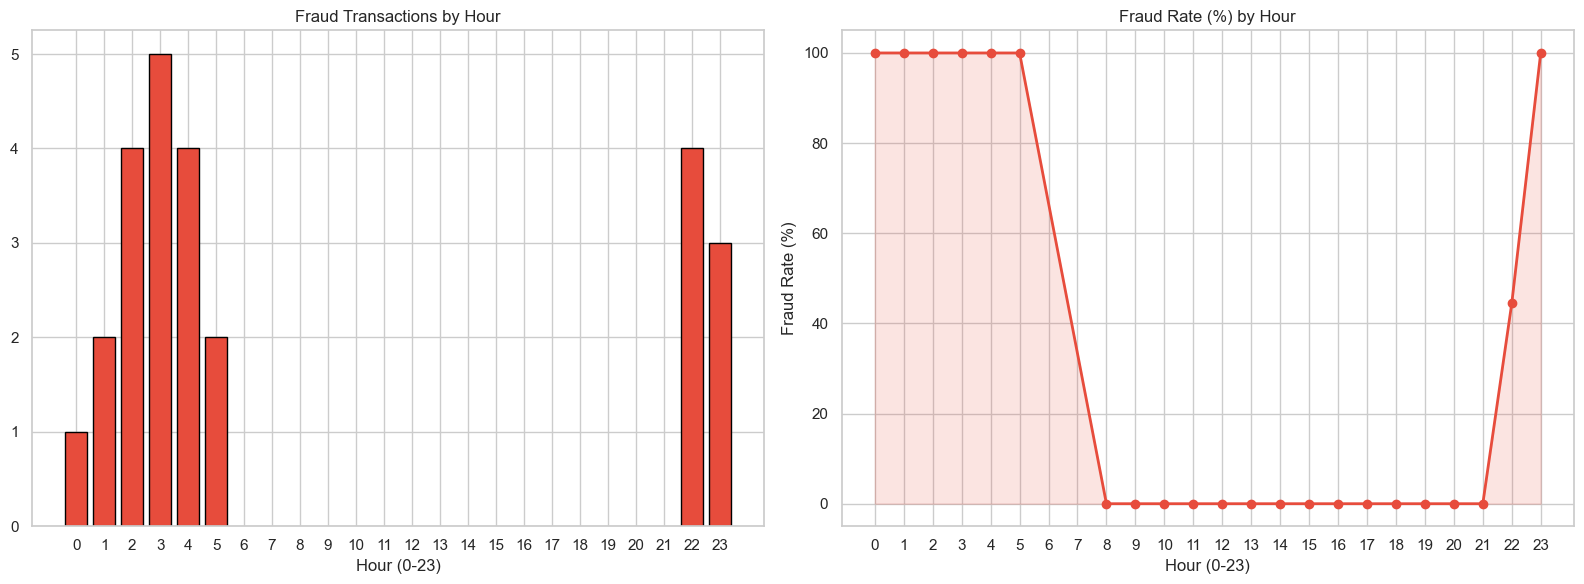

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# fraud count by hour
hour_fraud = df[df['is_fraud'] == 1]['transaction_hour'].value_counts().sort_index()
axes[0].bar(hour_fraud.index, hour_fraud.values, color='#e74c3c', edgecolor='black')
axes[0].set_title('Fraud Transactions by Hour')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_xticks(range(0, 24))

# fraud rate by hour
hour_rate = df.groupby('transaction_hour')['is_fraud'].mean() * 100
axes[1].plot(hour_rate.index, hour_rate.values, marker='o', color='#e74c3c', linewidth=2)
axes[1].fill_between(hour_rate.index, hour_rate.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('Fraud Rate (%) by Hour')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('plots/03_hour_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Fraud spikes during late night and early morning hours (midnight to ~5 AM). Makes sense -- cardholders are asleep and won't notice unauthorized activity.

### Plot 4 -- Merchant Category Analysis

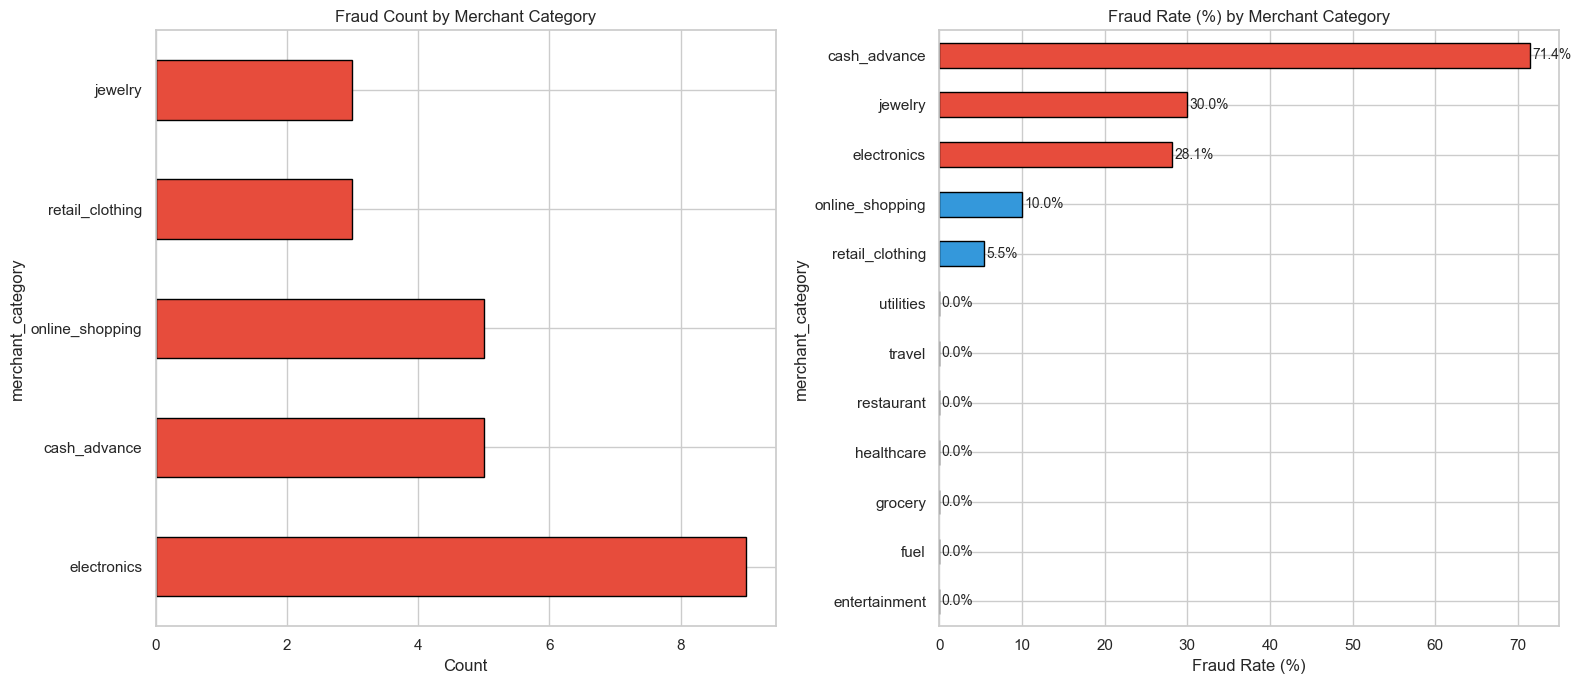

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# fraud count
fraud_merchant = df[df['is_fraud'] == 1]['merchant_category'].value_counts()
fraud_merchant.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Fraud Count by Merchant Category')
axes[0].set_xlabel('Count')

# fraud rate
rate_merchant = df.groupby('merchant_category')['is_fraud'].mean().sort_values() * 100
bar_colors = ['#e74c3c' if v > 10 else '#3498db' for v in rate_merchant.values]
rate_merchant.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='black')
axes[1].set_title('Fraud Rate (%) by Merchant Category')
axes[1].set_xlabel('Fraud Rate (%)')

for i, val in enumerate(rate_merchant.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/04_merchant_category.png', dpi=150, bbox_inches='tight')
plt.show()

Cash advance, electronics, jewelry, and online shopping have the highest fraud rates. These involve high-value items that can be resold quickly.

### Plot 5 -- Correlation Heatmap

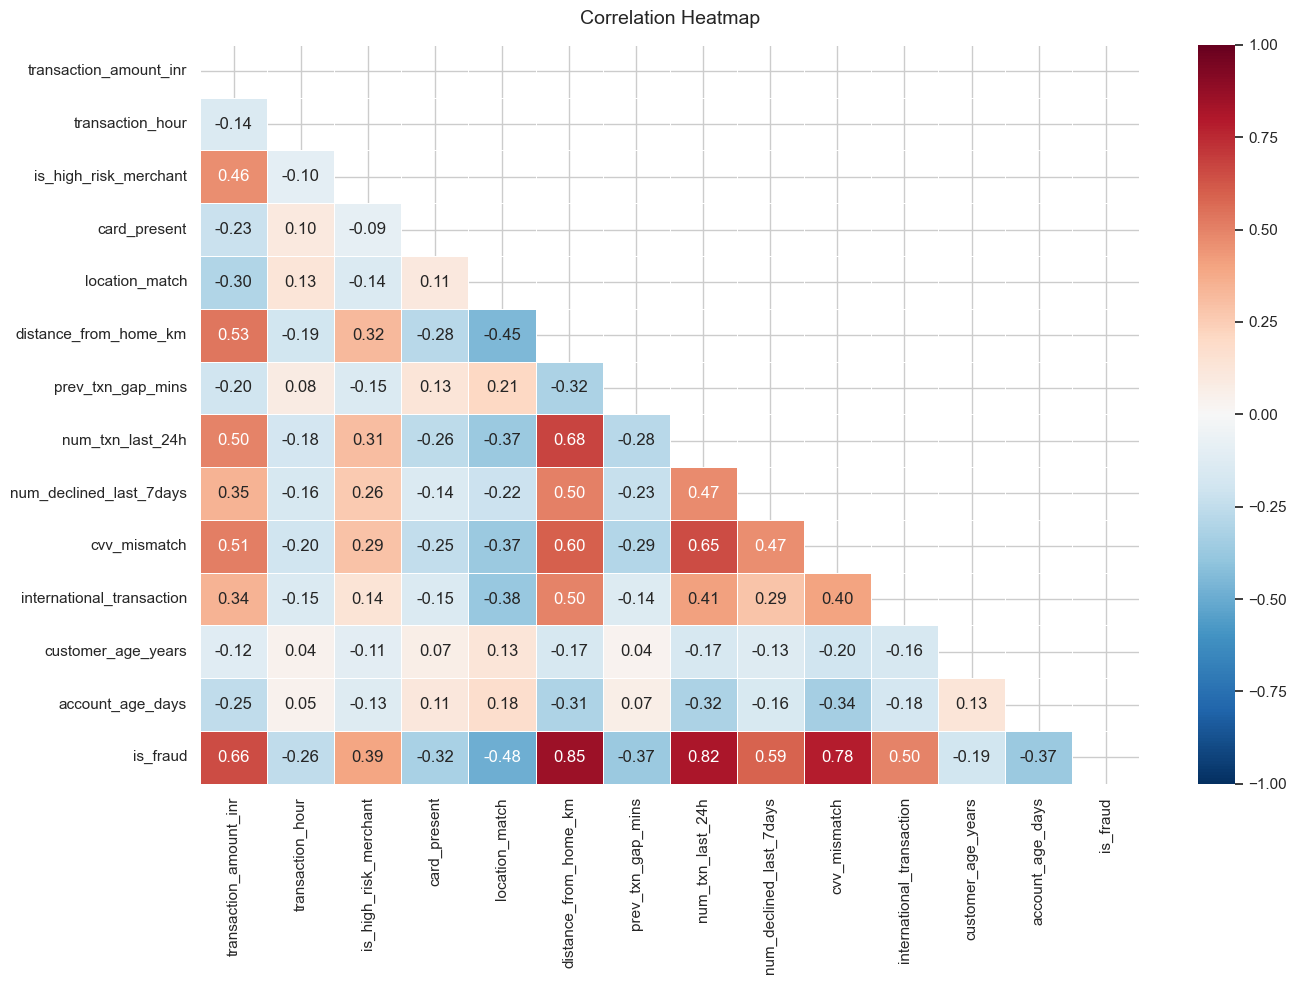


Correlation with is_fraud (sorted):
distance_from_home_km        0.853
num_txn_last_24h             0.818
cvv_mismatch                 0.782
transaction_amount_inr       0.655
num_declined_last_7days      0.590
international_transaction    0.498
location_match              -0.485
is_high_risk_merchant        0.393
prev_txn_gap_mins           -0.373
account_age_days            -0.367
card_present                -0.321
transaction_hour            -0.257
customer_age_years          -0.194
Name: is_fraud, dtype: float64


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('transaction_id')  # not a real feature

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# features most correlated with fraud
print("\nCorrelation with is_fraud (sorted):")
fraud_corr = corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
print(fraud_corr.round(3))

Strongest positive correlations with fraud: num_txn_last_24h, cvv_mismatch, distance_from_home_km, is_high_risk_merchant. Strongest negative: account_age_days, prev_txn_gap_mins, card_present, location_match.

### Plot 6 -- Key Feature Comparison (Fraud vs Genuine)

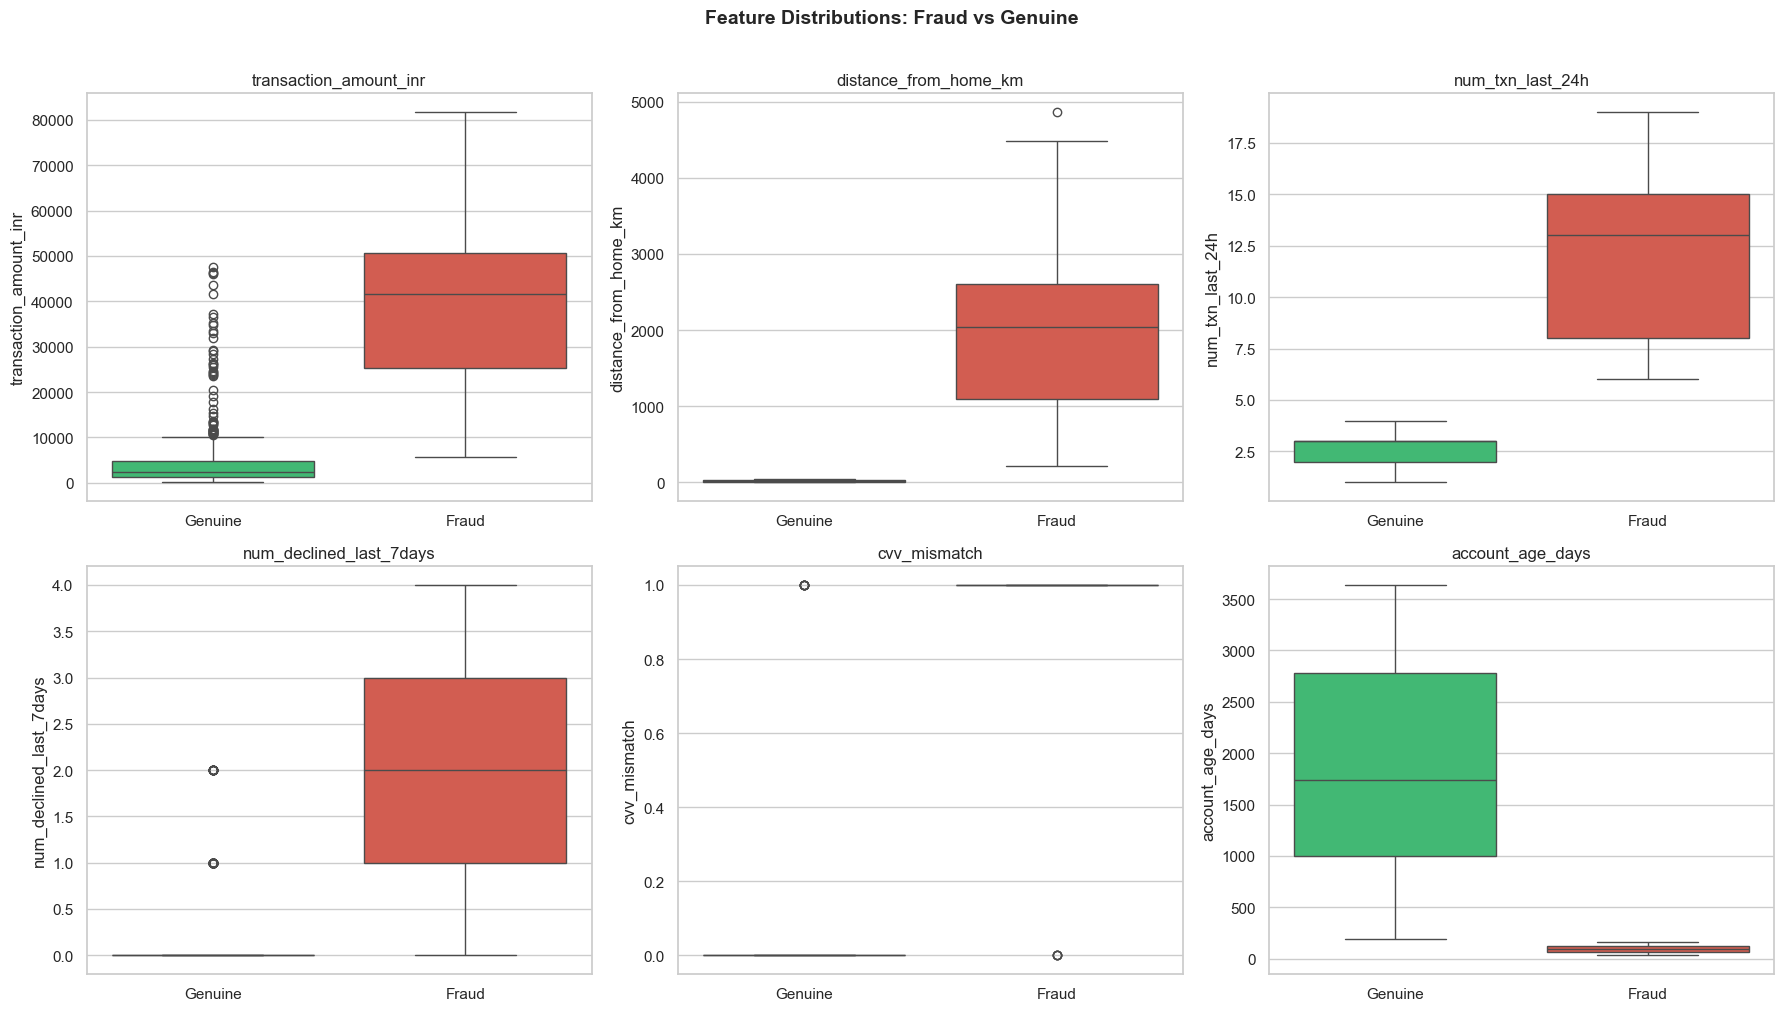

In [14]:
plot_features = ['transaction_amount_inr', 'distance_from_home_km', 'num_txn_last_24h',
                 'num_declined_last_7days', 'cvv_mismatch', 'account_age_days']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    data = df[[feat, 'is_fraud']].copy()
    data['is_fraud'] = data['is_fraud'].map({0: 'Genuine', 1: 'Fraud'})
    sns.boxplot(data=data, x='is_fraud', y=feat,
                palette={'Genuine': '#2ecc71', 'Fraud': '#e74c3c'}, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions: Fraud vs Genuine', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/06_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Clear separation between fraud and genuine across all these features. Fraud shows higher amounts, greater distance from home, more rapid transactions, more declines, more CVV mismatches, and newer accounts.

### Plot 7 -- Account Age vs Fraud Rate

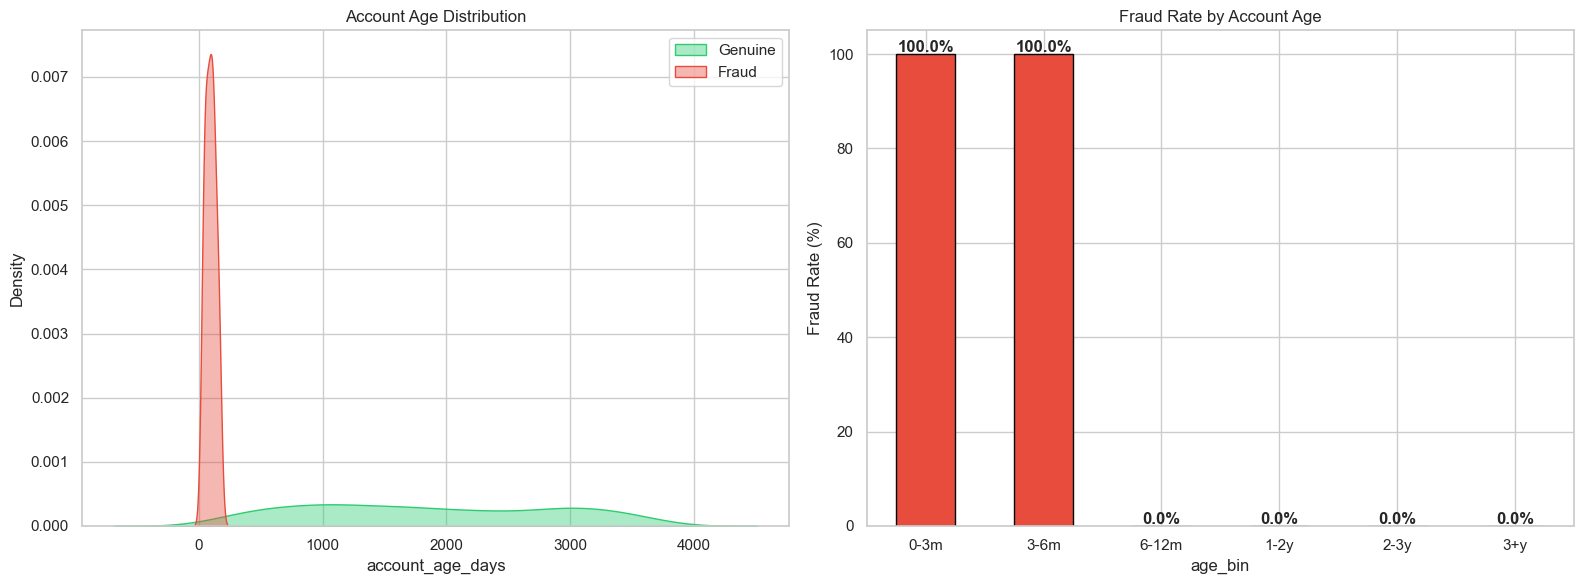

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE comparison
sns.kdeplot(data=df[df['is_fraud'] == 0], x='account_age_days', ax=axes[0],
            fill=True, alpha=0.4, color='#2ecc71', label='Genuine')
sns.kdeplot(data=df[df['is_fraud'] == 1], x='account_age_days', ax=axes[0],
            fill=True, alpha=0.4, color='#e74c3c', label='Fraud')
axes[0].set_title('Account Age Distribution')
axes[0].legend()

# fraud rate by age group
df['age_bin'] = pd.cut(df['account_age_days'],
                       bins=[0, 90, 180, 365, 730, 1095, 3650],
                       labels=['0-3m', '3-6m', '6-12m', '1-2y', '2-3y', '3+y'])

rate_age = df.groupby('age_bin', observed=True)['is_fraud'].mean() * 100
bar_colors = ['#e74c3c' if v > 5 else '#3498db' for v in rate_age.values]
rate_age.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='black')
axes[1].set_title('Fraud Rate by Account Age')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(rate_age.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

df.drop('age_bin', axis=1, inplace=True)

plt.tight_layout()
plt.savefig('plots/07_account_age.png', dpi=150, bbox_inches='tight')
plt.show()

New accounts (under 6 months) have a much higher fraud rate. Fraud drops off sharply as account age increases. Fraudsters either create fake accounts or target freshly compromised ones.

---
### EDA Summary

- Dataset is imbalanced, SMOTE needed.
- Fraud transactions have higher amounts, happen at odd hours, and target high-value merchant categories.
- Top fraud indicators: cvv_mismatch, distance_from_home, num_txn_last_24h, num_declined_last_7days, low account_age_days.
- No missing values, dataset is clean.

---